# 05 — Tree-Based Models
**Loan Approval Prediction**

Goals:
- Train a Decision Tree classifier
- Train a Random Forest ensemble
- Bonus: Gradient Boosting
- Tune hyperparameters (max_depth, n_estimators) via cross-validation
- Analyse feature importance
- Compare models with and without SMOTE

**Prerequisite**: Notebooks 02 and 03 must have been run.

---

In [12]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # make src/ importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

from sklearn.model_selection import cross_val_score
from sklearn.tree import plot_tree

from src.config import (
    DATA_DIR, MODELS_DIR,
    DT_MODEL_FILE, RF_MODEL_FILE, GB_MODEL_FILE,
    RANDOM_STATE,
)
from src.models import (
    get_decision_tree,
    get_random_forest,
    get_gradient_boosting,
    evaluate_model,
    plot_confusion_matrix,
    plot_roc_curves,
    plot_feature_importance,
)

warnings.filterwarnings('ignore')
print("Imports OK — Data dir:", DATA_DIR)

Imports OK — Data dir: /mnt/c/Users/Mega-PC/Desktop/stage Elevvo/Task_4_Loan_Approval_Prediction/data


## 1. Load Data

In [13]:
import numpy as np

X_train = np.load(os.path.join(DATA_DIR, 'X_train.npy'))
X_test  = np.load(os.path.join(DATA_DIR, 'X_test.npy'))
y_train = np.load(os.path.join(DATA_DIR, 'y_train.npy'))
y_test  = np.load(os.path.join(DATA_DIR, 'y_test.npy'))
X_smote = np.load(os.path.join(DATA_DIR, 'X_smote.npy'))
y_smote = np.load(os.path.join(DATA_DIR, 'y_smote.npy'))

with open(os.path.join(DATA_DIR, 'feature_names.pkl'), 'rb') as f:
    feature_names = pickle.load(f)

print(f"Train  : {X_train.shape}")
print(f"SMOTE  : {X_smote.shape}")
print(f"Test   : {X_test.shape}")
print(f"Feature names ({len(feature_names)}): {feature_names}")

Train  : (3415, 11)
SMOTE  : (4250, 11)
Test   : (854, 11)
Feature names (11): ['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


## 2. Decision Tree — Baseline

In [14]:
dt_base = get_decision_tree(max_depth=None)
dt_base.fit(X_train, y_train)
evaluate_model(dt_base, X_test, y_test, "Decision Tree — No depth limit")


═══════════════════════════════════════════════════════
  Decision Tree — No depth limit  —  Evaluation on Test Set
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

Rejected (0)       0.98      0.98      0.98       323
Approved (1)       0.98      0.98      0.98       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854

  ROC-AUC : 0.9801


{'model': 'Decision Tree — No depth limit',
 'accuracy': np.float64(0.9812646370023419),
 'f1_approved': 0.9849340866290018,
 'f1_rejected': 0.9752321981424149,
 'f1_macro': 0.9800831423857084,
 'f1_weighted': 0.9812646370023419,
 'roc_auc': 0.9800831423857084}

## 3. Decision Tree — Depth Tuning

  max_depth=2      CV Macro-F1 = 0.9571
  max_depth=3      CV Macro-F1 = 0.9666
  max_depth=4      CV Macro-F1 = 0.9592
  max_depth=5      CV Macro-F1 = 0.9711
  max_depth=6      CV Macro-F1 = 0.9649
  max_depth=8      CV Macro-F1 = 0.9673
  max_depth=10     CV Macro-F1 = 0.9746
  max_depth=None   CV Macro-F1 = 0.9762

Best max_depth = None  (CV Macro-F1 = 0.9762)


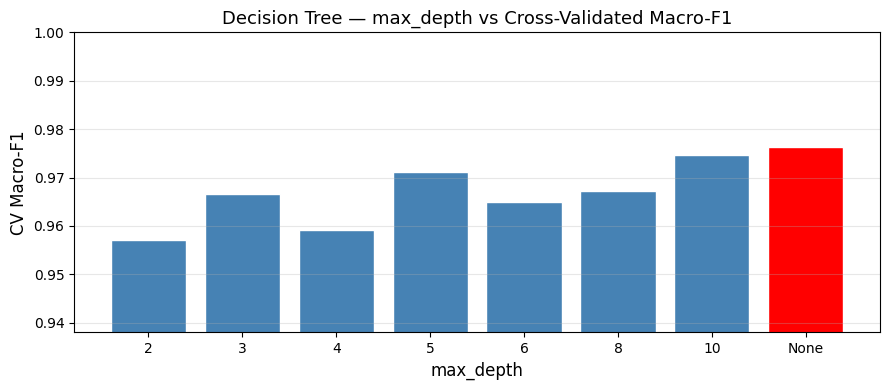

In [15]:
depths = [2, 3, 4, 5, 6, 8, 10, None]
cv_scores_dt = []

for d in depths:
    model = get_decision_tree(max_depth=d)
    score = cross_val_score(
        model, X_smote, y_smote, cv=5, scoring='f1_macro', n_jobs=-1
    ).mean()
    cv_scores_dt.append(score)
    label = str(d) if d is not None else 'None'
    print(f"  max_depth={label:<5}  CV Macro-F1 = {score:.4f}")

best_depth = depths[int(np.argmax(cv_scores_dt))]
print(f"\nBest max_depth = {best_depth}  (CV Macro-F1 = {max(cv_scores_dt):.4f})")

# Bar chart of depth vs CV-F1
labels_plot = [str(d) if d is not None else 'None' for d in depths]
fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = ['red' if d == best_depth else 'steelblue' for d in depths]
ax.bar(labels_plot, cv_scores_dt, color=bar_colors, edgecolor='white')
ax.set_xlabel('max_depth', fontsize=12)
ax.set_ylabel('CV Macro-F1', fontsize=12)
ax.set_title('Decision Tree — max_depth vs Cross-Validated Macro-F1', fontsize=13)
ax.set_ylim(min(cv_scores_dt) * 0.98, 1.0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Decision Tree — Best Model


═══════════════════════════════════════════════════════
  Decision Tree — max_depth=None (SMOTE)  —  Evaluation on Test Set
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

Rejected (0)       0.98      0.97      0.97       323
Approved (1)       0.98      0.99      0.98       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854

  ROC-AUC : 0.9764


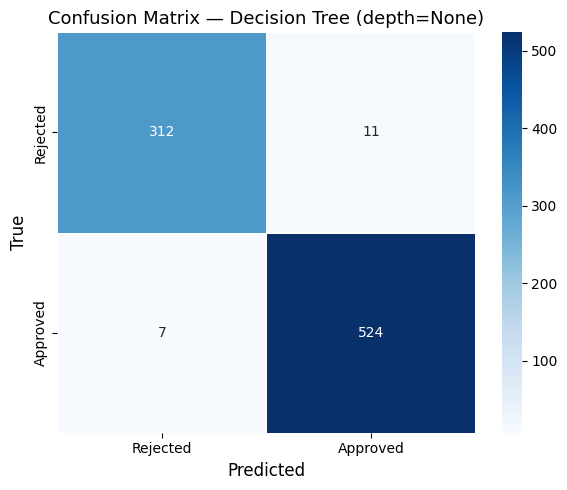

array([[312,  11],
       [  7, 524]])

In [16]:
dt_best = get_decision_tree(max_depth=best_depth)
dt_best.fit(X_smote, y_smote)
metrics_dt = evaluate_model(
    dt_best, X_test, y_test,
    f"Decision Tree — max_depth={best_depth} (SMOTE)"
)
plot_confusion_matrix(
    y_test,
    dt_best.predict(X_test),
    f"Confusion Matrix — Decision Tree (depth={best_depth})"
)

## 5. Decision Tree Visualisation (depth ≤ 3)

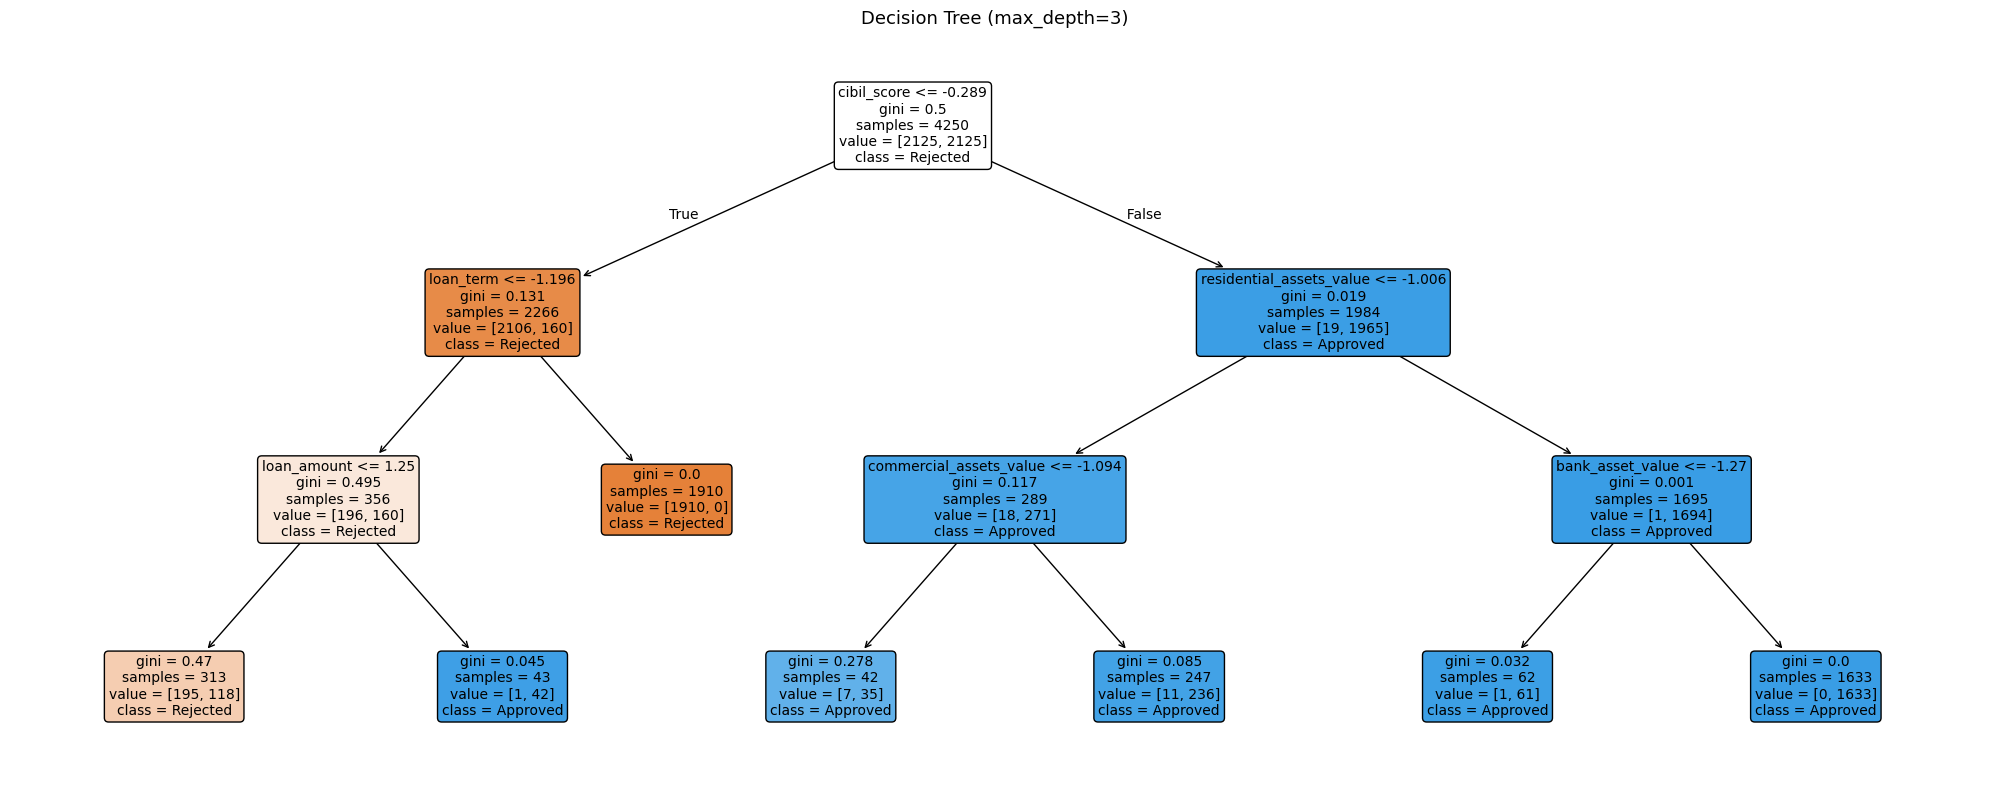

In [17]:
dt_vis = get_decision_tree(max_depth=3)
dt_vis.fit(X_smote, y_smote)

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt_vis,
    ax=ax,
    feature_names=feature_names,
    class_names=['Rejected', 'Approved'],
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.title('Decision Tree (max_depth=3)', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Random Forest — Training


═══════════════════════════════════════════════════════
  Random Forest (100 trees, SMOTE)  —  Evaluation on Test Set
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

Rejected (0)       0.98      0.98      0.98       323
Approved (1)       0.98      0.99      0.99       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854

  ROC-AUC : 0.9988


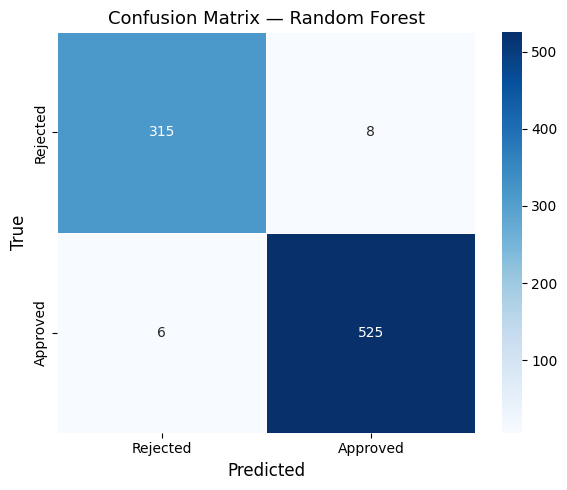

array([[315,   8],
       [  6, 525]])

In [18]:
rf_model = get_random_forest(n_estimators=100)
rf_model.fit(X_smote, y_smote)
metrics_rf = evaluate_model(rf_model, X_test, y_test, "Random Forest (100 trees, SMOTE)")
plot_confusion_matrix(
    y_test,
    rf_model.predict(X_test),
    "Confusion Matrix — Random Forest"
)

## 7. Random Forest — n_estimators Tuning

  n_estimators=10    CV Macro-F1 = 0.9720
  n_estimators=25    CV Macro-F1 = 0.9765
  n_estimators=50    CV Macro-F1 = 0.9798
  n_estimators=100   CV Macro-F1 = 0.9807
  n_estimators=200   CV Macro-F1 = 0.9800
  n_estimators=300   CV Macro-F1 = 0.9798

Best n_estimators = 100  (CV Macro-F1 = 0.9807)


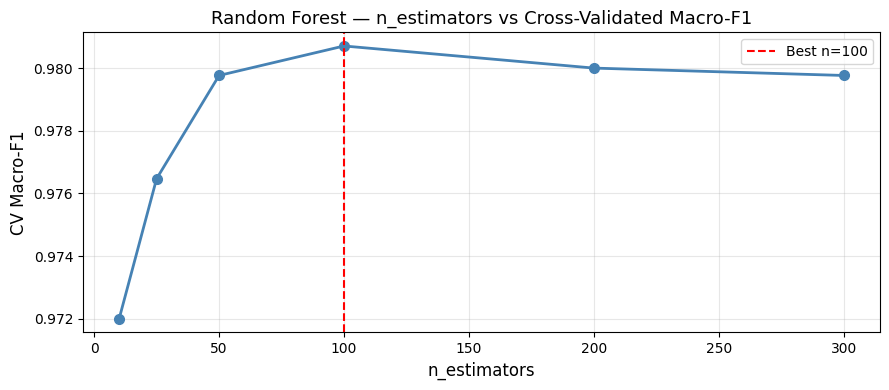


═══════════════════════════════════════════════════════
  Random Forest — 100 trees (SMOTE)  —  Evaluation on Test Set
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

Rejected (0)       0.98      0.98      0.98       323
Approved (1)       0.98      0.99      0.99       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854

  ROC-AUC : 0.9988


In [19]:
n_estimators_list = [10, 25, 50, 100, 200, 300]
cv_scores_rf = []

for n in n_estimators_list:
    model = get_random_forest(n_estimators=n)
    score = cross_val_score(
        model, X_smote, y_smote, cv=5, scoring='f1_macro', n_jobs=-1
    ).mean()
    cv_scores_rf.append(score)
    print(f"  n_estimators={n:<4}  CV Macro-F1 = {score:.4f}")

best_n = n_estimators_list[int(np.argmax(cv_scores_rf))]
print(f"\nBest n_estimators = {best_n}  (CV Macro-F1 = {max(cv_scores_rf):.4f})")

# Plot n_estimators vs CV-F1
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(n_estimators_list, cv_scores_rf, marker='o', color='steelblue', lw=2, markersize=7)
ax.axvline(best_n, color='red', linestyle='--', label=f'Best n={best_n}')
ax.set_xlabel('n_estimators', fontsize=12)
ax.set_ylabel('CV Macro-F1', fontsize=12)
ax.set_title('Random Forest — n_estimators vs Cross-Validated Macro-F1', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Train best Random Forest
rf_best = get_random_forest(n_estimators=best_n)
rf_best.fit(X_smote, y_smote)
metrics_rf_best = evaluate_model(
    rf_best, X_test, y_test,
    f"Random Forest — {best_n} trees (SMOTE)"
)

## 8. Gradient Boosting


═══════════════════════════════════════════════════════
  Gradient Boosting (SMOTE)  —  Evaluation on Test Set
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

Rejected (0)       0.97      0.97      0.97       323
Approved (1)       0.98      0.98      0.98       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854

  ROC-AUC : 0.9983


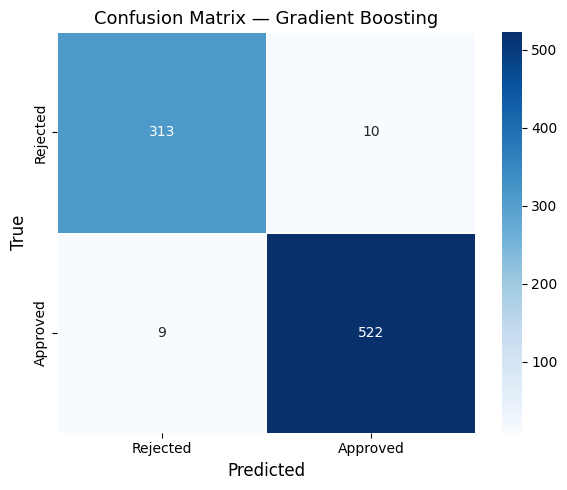

array([[313,  10],
       [  9, 522]])

In [20]:
gb_model = get_gradient_boosting(n_estimators=100, max_depth=3, learning_rate=0.1)
gb_model.fit(X_smote, y_smote)
metrics_gb = evaluate_model(gb_model, X_test, y_test, "Gradient Boosting (SMOTE)")
plot_confusion_matrix(
    y_test,
    gb_model.predict(X_test),
    "Confusion Matrix — Gradient Boosting"
)

## 9. Feature Importance

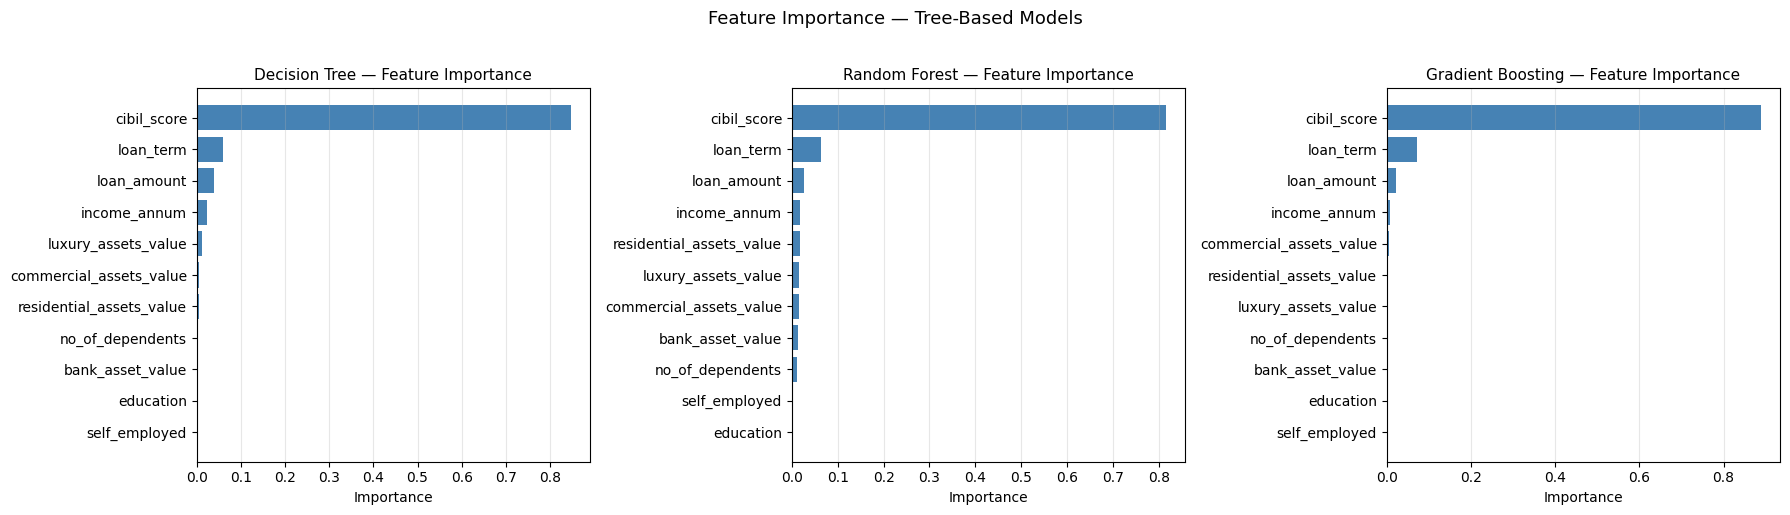

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

tree_models_named = [
    ('Decision Tree',     dt_best),
    ('Random Forest',     rf_best),
    ('Gradient Boosting', gb_model),
]

for ax, (name, model) in zip(axes, tree_models_named):
    importances = model.feature_importances_
    indices     = np.argsort(importances)[::-1]
    ax.barh(
        [feature_names[i] for i in indices[::-1]],
        importances[indices[::-1]],
        color='steelblue',
    )
    ax.set_title(f'{name} — Feature Importance', fontsize=11)
    ax.set_xlabel('Importance')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Feature Importance — Tree-Based Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 10. ROC Comparison — Tree Models

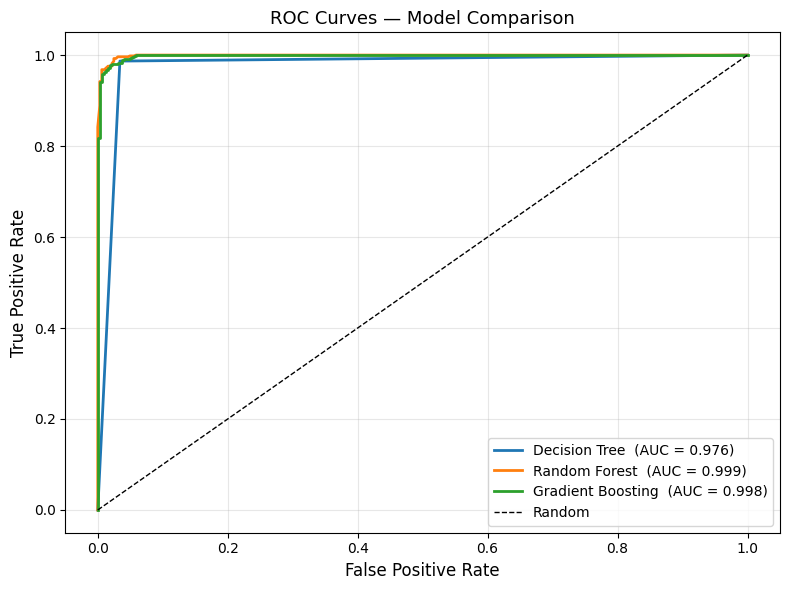

In [22]:
tree_models = {
    'Decision Tree'    : dt_best,
    'Random Forest'    : rf_best,
    'Gradient Boosting': gb_model,
}

plot_roc_curves(tree_models, X_test, y_test)

## 11. Save Models

In [23]:
import pickle

os.makedirs(MODELS_DIR, exist_ok=True)

for path, model in [
    (DT_MODEL_FILE, dt_best),
    (RF_MODEL_FILE, rf_best),
    (GB_MODEL_FILE, gb_model),
]:
    with open(path, 'wb') as f:
        pickle.dump(model, f)
    print(f"Saved → {path}")

# Summary of tree model variants
summary = pd.DataFrame([metrics_dt, metrics_rf, metrics_rf_best, metrics_gb])
summary = summary.set_index('model')
print("\nSummary — Tree-Based Models:")
display(summary[['accuracy', 'f1_macro', 'f1_approved', 'f1_rejected', 'roc_auc']].round(4))

Saved → /mnt/c/Users/Mega-PC/Desktop/stage Elevvo/Task_4_Loan_Approval_Prediction/models/decision_tree.pkl
Saved → /mnt/c/Users/Mega-PC/Desktop/stage Elevvo/Task_4_Loan_Approval_Prediction/models/random_forest.pkl
Saved → /mnt/c/Users/Mega-PC/Desktop/stage Elevvo/Task_4_Loan_Approval_Prediction/models/gradient_boosting.pkl

Summary — Tree-Based Models:


,accuracy,f1_macro,f1_approved,f1_rejected,roc_auc
model,,,,,
Decision Tree — max_depth=None (SMOTE),0.9789,0.9775,0.9831,0.9720,0.9764
"Random Forest (100 trees, SMOTE)",0.9836,0.9826,0.9868,0.9783,0.9988
Random Forest — 100 trees (SMOTE),0.9836,0.9826,0.9868,0.9783,0.9988
Gradient Boosting (SMOTE),0.9778,0.9763,0.9821,0.9705,0.9983
